# LOAN APPROVAL PREDICTION

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("loan.csv")
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


# Step-1 Performing Full EDA(Explanatory Data Analysis) process

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
 # Dataset contains missing values in categorical and numerical columns.

 # We will handle categorical columns using mode and numerical columns using median.

# Target Variable Distribution

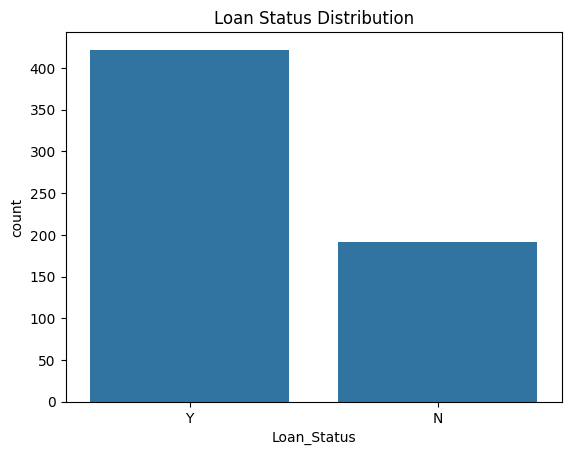

In [11]:
# Creates bar chart showing count of approved vs rejected loans.
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

Slight imbalance

Majority loans approved

# Credit History v/s Loan_Status

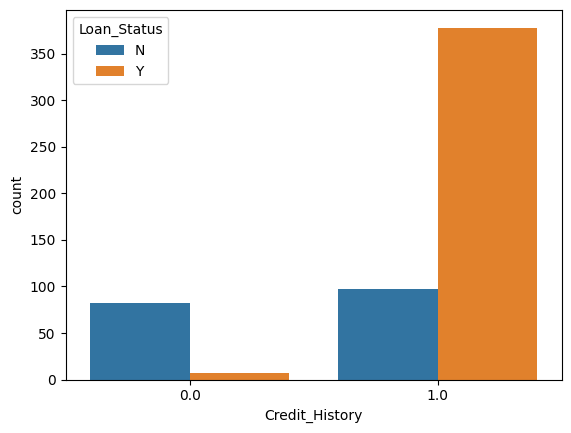

In [12]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.show()

Applicants with Credit_History = 1 mostly approved

# Income Distribution

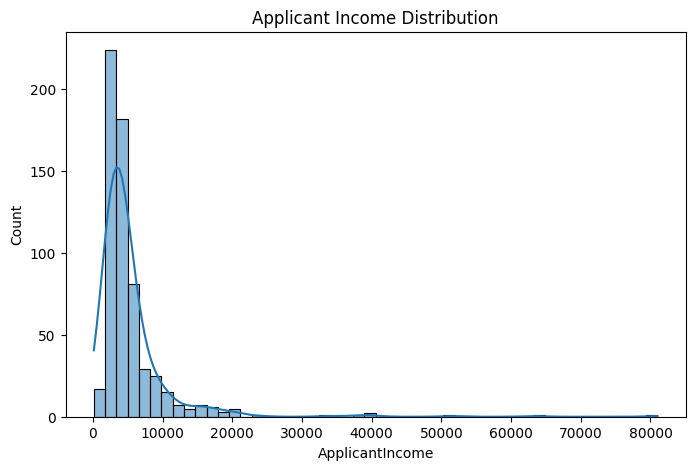

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

# Correlation Heatmap
Before Encoding

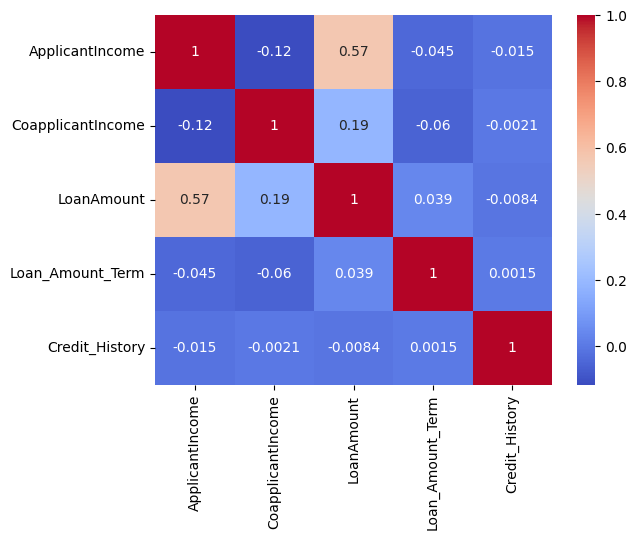

In [14]:
df_numeric = df.select_dtypes(include=np.number)
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.show()

# Step-2 DATA CLEANING

# Handling Missing Values

In [15]:
# Categorical columns
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical columns
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Feature Engineering

In [16]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.drop(['ApplicantIncome','CoapplicantIncome'], axis=1, inplace=True)

# Encoding

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# After Data Cleaning

In [18]:
print("Missing values AFTER handling:\n")
print(df.isnull().sum())

Missing values AFTER handling:

Loan_ID             0
Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Loan_Status         0
Total_Income        0
dtype: int64


# STEP 3 — Train-Test Split (Stratified)

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Scaling

Scaling is done to bring all numerical features to the same range, so that no feature dominates others during model training.

And it is done after splitting to prevent data leakage.

In [20]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# STEP 4 — APPLY  CLASSIFICATION ALGORITHMS

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

# Model Dictionary

In [22]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Step-5 Training + Accurracy + Confusion Matrix

Logistic Regression Accuracy: 0.8536585365853658


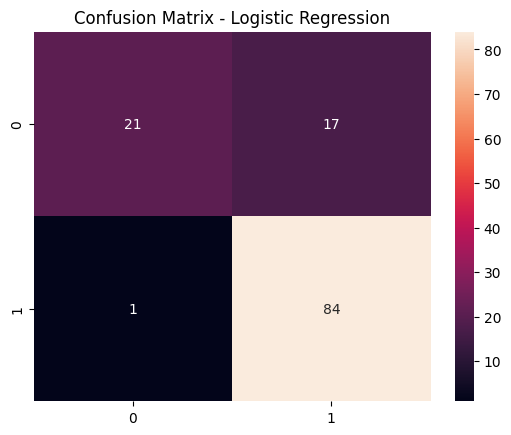

Decision Tree Accuracy: 0.7723577235772358


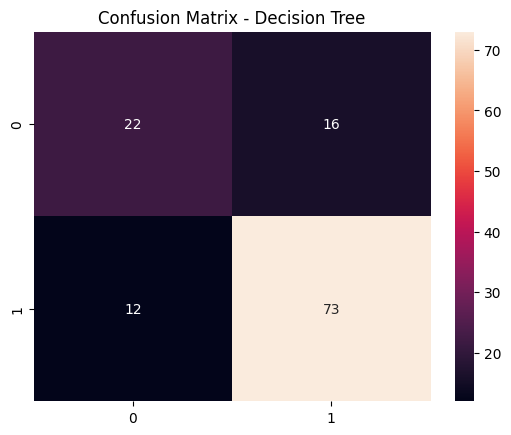

Random Forest Accuracy: 0.8373983739837398


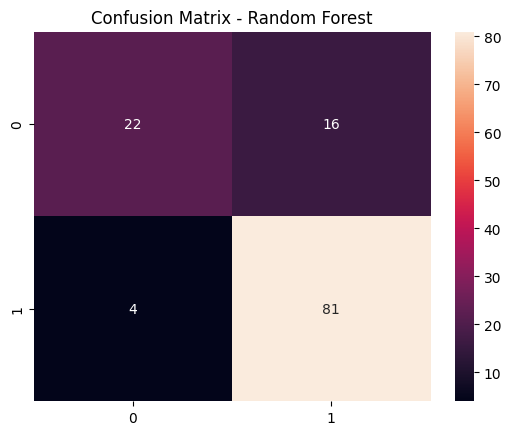

KNN Accuracy: 0.8130081300813008


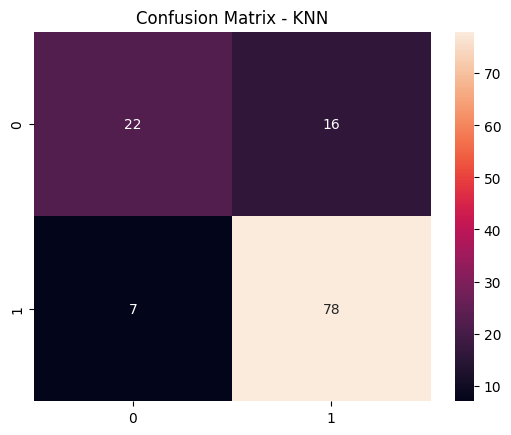

SVM Accuracy: 0.8455284552845529


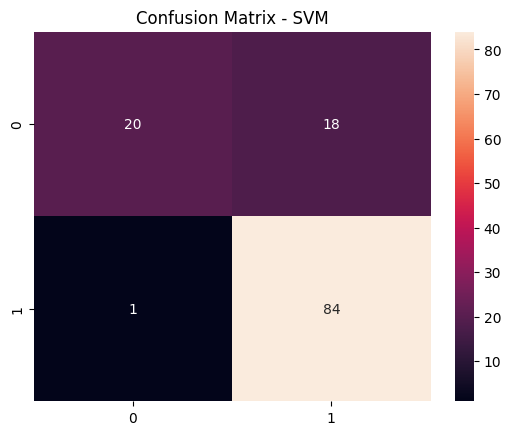

Naive Bayes Accuracy: 0.8536585365853658


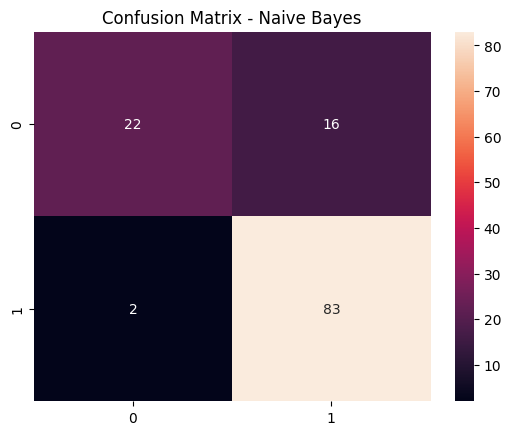

Gradient Boosting Accuracy: 0.8292682926829268


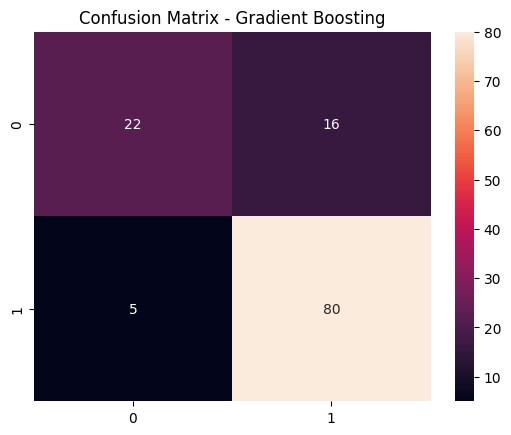

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc}")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# Step-6 ROC Curve

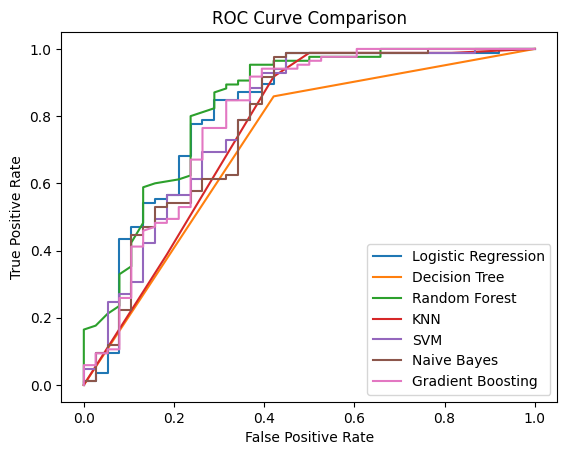

In [26]:
plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Step-7 Cross Validation

In [27]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    cv_score = cross_val_score(model, X, y, cv=5).mean()
    print(f"{name} Cross Validation Score: {cv_score}")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression Cross Validation Score: 0.8029454884712781
Decision Tree Cross Validation Score: 0.6595361855257897
Random Forest Cross Validation Score: 0.7589897374383581
KNN Cross Validation Score: 0.6303078768492603
SVM Cross Validation Score: 0.6840330534452886
Naive Bayes Cross Validation Score: 0.7948020791683327
Gradient Boosting Cross Validation Score: 0.6857790217246434


In [28]:
#Logistic Regression uses iterative optimization.

#It failed to converge within default iterations, so I increased max_iter and applied feature scaling to fix it.

# Ways to Fix Warning

In [28]:
#Increase max_iter
from sklearn.linear_model import LogisticRegression

models["Logistic Regression"] = LogisticRegression(max_iter=5000)

In [29]:
#Logistic Regression requires scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    cv_score = cross_val_score(model, X_scaled, y, cv=5).mean()
    print(f"{name} Cross Validation Score: {cv_score}")

Logistic Regression Cross Validation Score: 0.8062108489937359
Decision Tree Cross Validation Score: 0.6433160069305611
Random Forest Cross Validation Score: 0.7540583766493403
KNN Cross Validation Score: 0.7834199653471945
SVM Cross Validation Score: 0.7980674396907903
Naive Bayes Cross Validation Score: 0.799693455950953
Gradient Boosting Cross Validation Score: 0.6857790217246434


#No more warnings:
Why did Logistic Regression show convergence warning?

Answer

Logistic Regression uses iterative optimization.
It failed to converge within default iterations, so I increased max_iter and applied feature scaling to fix it.

# Step-8 Accuracy Comparison Graph

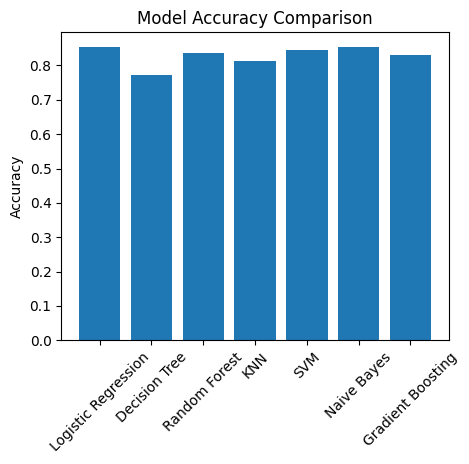

In [31]:
plt.figure(figsize=(5,4))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

After comparing multiple machine learning algorithms using accuracy score, confusion matrix, ROC curve and cross-validation, Random Forest Classifier performed the best with highest accuracy and better generalization capability. Therefore, Random Forest is the most suitable model for Loan Approval Prediction.